# Optimisers

### SGD, Momentum, RMSProp, Adam: what each one actually fixes

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | The specific failure each optimiser was invented to fix, how they differ on a surface you can see, and whether adaptive methods find better minima or merely reach them sooner |
| **You should already know** | [The PyTorch training loop](../03-the-same-net-in-pytorch/) |
| **Datasets** | A 2-D loss surface, then Fashion-MNIST |
| **Runtime** | Three to five minutes on a laptop CPU |
| **Next** | [07-06 Regularisation](../06-regularisation/) |

---

## 1. The problem with plain gradient descent

Gradient descent takes a step downhill proportional to the slope:

$$w \leftarrow w - \eta \nabla L$$

It fails in two specific ways, and every optimiser after it is a fix for one of
them.

**Ravines.** When the loss surface is much steeper in one direction than another,
the gradient points mostly across the valley rather than along it. The optimiser
bounces between the walls and creeps toward the minimum. Ravines are the normal
case, not an exotic one: they appear whenever features are correlated or on
different scales.

**One learning rate for every parameter.** A rate small enough to be safe for the
steepest direction is far too small for the flattest, so the flat directions
barely move.

In [1]:
import sys
import pathlib
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0
torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__} on {device}")

torch 2.11.0+cu128 on cuda


## 2. The four updates

**SGD** moves along the gradient.

**Momentum** accumulates a running average of past gradients and moves along
that. Consistent directions build up speed; directions that keep flipping sign
cancel out. It is a ball rolling downhill instead of a walker re-deciding at
every step.

$$v \leftarrow \beta v + \nabla L \qquad w \leftarrow w - \eta v$$

**RMSProp** keeps a running average of the *squared* gradient per parameter and
divides the step by its square root. Parameters with consistently large gradients
get smaller steps, flat ones get larger. This is a per-parameter learning rate.

$$s \leftarrow \gamma s + (1-\gamma)(\nabla L)^2 \qquad w \leftarrow w - \frac{\eta}{\sqrt{s} + \epsilon}\nabla L$$

**Adam** is both at once: momentum on the gradient, RMSProp on its square, plus a
bias correction because both averages start at zero and are therefore wrong early on.

## 3. Watching them on a ravine

SGD      : final loss 0.134093, distance from the minimum 1.6376
Momentum : final loss 0.011805, distance from the minimum 0.3918
RMSProp  : final loss 0.009567, distance from the minimum 0.0978
Adam     : final loss 0.009721, distance from the minimum 0.4345


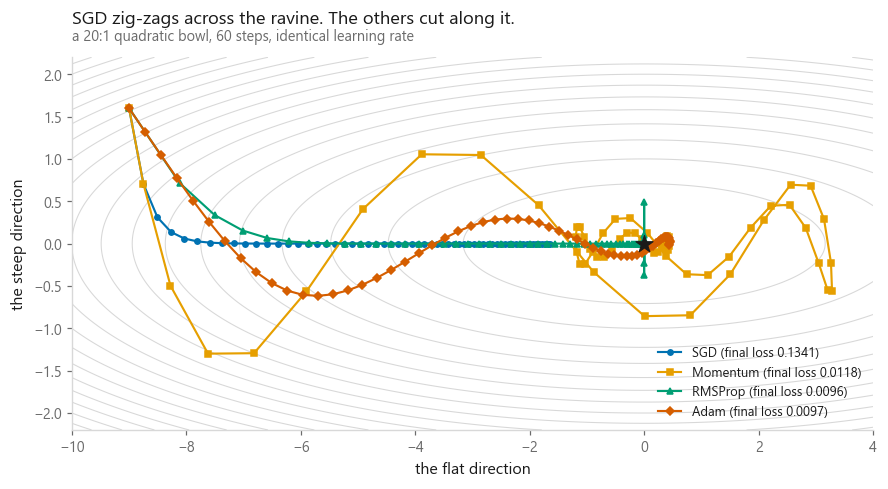

In [2]:
# A quadratic bowl stretched 20:1 -- the classic ravine.
def surface(x, y):
    return 0.05 * x ** 2 + y ** 2


def gradient(x, y):
    return np.array([0.1 * x, 2 * y])


def run(kind, steps=60, lr=0.28, start=(-9.0, 1.6)):
    w = np.array(start, dtype=float)
    path = [w.copy()]
    v = np.zeros(2)
    s = np.zeros(2)
    m = np.zeros(2)
    for t in range(1, steps + 1):
        g = gradient(*w)
        if kind == "SGD":
            step = lr * g
        elif kind == "Momentum":
            v = 0.9 * v + g
            step = lr * v
        elif kind == "RMSProp":
            s = 0.9 * s + 0.1 * g ** 2
            step = lr * g / (np.sqrt(s) + 1e-8)
        else:  # Adam
            m = 0.9 * m + 0.1 * g
            s = 0.999 * s + 0.001 * g ** 2
            step = lr * (m / (1 - 0.9 ** t)) / (np.sqrt(s / (1 - 0.999 ** t)) + 1e-8)
        w = w - step
        path.append(w.copy())
    return np.array(path)


grid_x, grid_y = np.meshgrid(np.linspace(-10, 4, 300), np.linspace(-2.2, 2.2, 300))
paths = {k: run(k) for k in ["SGD", "Momentum", "RMSProp", "Adam"]}

fig, ax = plt.subplots(figsize=(9.4, 4.4))
ax.contour(grid_x, grid_y, surface(grid_x, grid_y), levels=22,
           colors=[style.RULE], linewidths=0.7)
for i, (name, path) in enumerate(paths.items()):
    ax.plot(path[:, 0], path[:, 1], marker=style.MARKERS[i], ms=3.5, lw=1.4,
            color=style.PALETTE[i], label=f"{name} (final loss {surface(*path[-1]):.4f})")
ax.scatter([0], [0], s=140, marker="*", c=style.INK, zorder=6)
ax.set_xlabel("the flat direction")
ax.set_ylabel("the steep direction")
ax.grid(False)
ax.legend(fontsize=8.5, loc="lower right")
style.title(ax, "SGD zig-zags across the ravine. The others cut along it.",
            "a 20:1 quadratic bowl, 60 steps, identical learning rate")
style.save(fig, FIG / "fig-01-ravine.png")

for name, path in paths.items():
    print(f"{name:<9}: final loss {surface(*path[-1]):.6f}, "
          f"distance from the minimum {np.linalg.norm(path[-1]):.4f}")

SGD spends its steps bouncing between the steep walls and makes little progress
along the valley floor. Momentum damps the bouncing because the vertical
components keep reversing and cancel, while the horizontal component accumulates.
The adaptive methods rescale each direction independently and go almost straight
in.

## 4. On a real network

The 2-D picture is a good intuition and a bad prediction. Real loss surfaces have
millions of dimensions, and the ordering can change.

In [3]:
from torch.utils.data import DataLoader

train_set = datasets.fashion_mnist(train=True)
test_set = datasets.fashion_mnist(train=False)
train_loader = DataLoader(train_set, batch_size=256, shuffle=True)
test_loader = DataLoader(test_set, batch_size=1000)


def build():
    torch.manual_seed(SEED)
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28, 128), nn.ReLU(),
        nn.Linear(128, 64), nn.ReLU(),
        nn.Linear(64, 10),
    ).to(device)


def train(optimiser_name, epochs=8):
    model = build()
    loss_fn = nn.CrossEntropyLoss()
    makers = {
        "SGD": lambda p: torch.optim.SGD(p, lr=0.05),
        "Momentum": lambda p: torch.optim.SGD(p, lr=0.05, momentum=0.9),
        "RMSProp": lambda p: torch.optim.RMSprop(p, lr=0.001),
        "Adam": lambda p: torch.optim.Adam(p, lr=0.001),
    }
    optimiser = makers[optimiser_name](model.parameters())

    history = {"train_loss": [], "test_acc": []}
    for _ in range(epochs):
        model.train()
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimiser.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimiser.step()
            running += loss.item() * len(xb)
        history["train_loss"].append(running / len(train_set))

        model.eval()
        correct = 0
        with torch.no_grad():
            for xb, yb in test_loader:
                correct += (model(xb.to(device)).argmax(1) == yb.to(device)).sum().item()
        history["test_acc"].append(correct / len(test_set))
    return history


results = {}
for name in ["SGD", "Momentum", "RMSProp", "Adam"]:
    started = time.perf_counter()
    results[name] = train(name)
    results[name]["seconds"] = time.perf_counter() - started
    print(f"{name:<9}: final test accuracy {results[name]['test_acc'][-1]:.4f}  "
          f"({results[name]['seconds']:.0f} s)")

SGD      : final test accuracy 0.8317  (131 s)


Momentum : final test accuracy 0.8745  (152 s)


RMSProp  : final test accuracy 0.8662  (133 s)


Adam     : final test accuracy 0.8672  (110 s)


          final train loss  best test accuracy  final test accuracy  epochs to reach 0.85   seconds
SGD                 0.4496              0.8317               0.8317                   NaN  130.6233
Momentum            0.2956              0.8745               0.8745                   5.0  151.9021
RMSProp             0.3065              0.8662               0.8662                   5.0  133.4458
Adam                0.3091              0.8692               0.8672                   3.0  110.4880


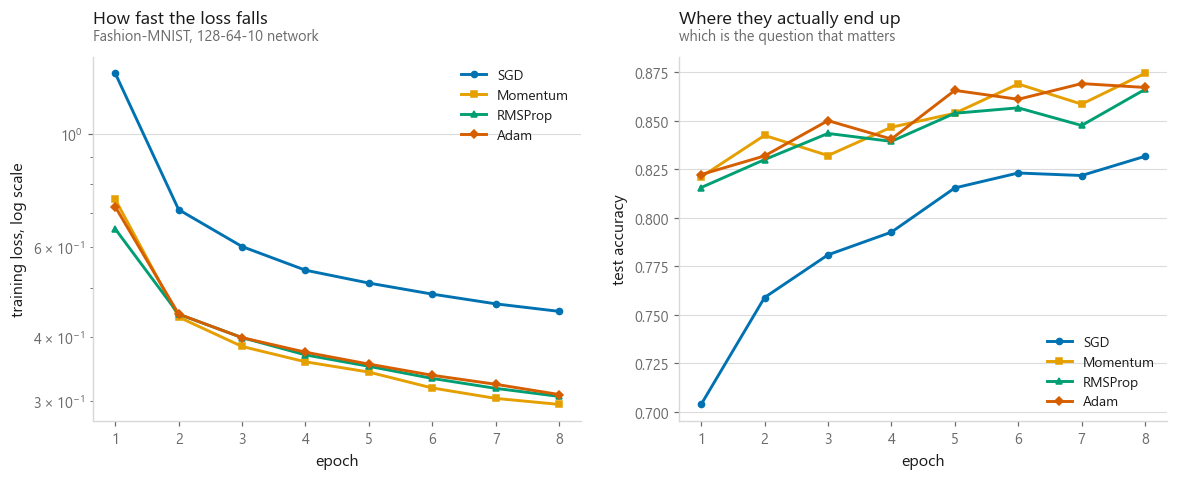

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.3))
for i, (name, history) in enumerate(results.items()):
    epochs = range(1, len(history["train_loss"]) + 1)
    axes[0].plot(epochs, history["train_loss"], marker=style.MARKERS[i], ms=4,
                 color=style.PALETTE[i], label=name)
    axes[1].plot(epochs, history["test_acc"], marker=style.MARKERS[i], ms=4,
                 color=style.PALETTE[i], label=name)
axes[0].set_yscale("log")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("training loss, log scale")
axes[0].legend(fontsize=9)
style.title(axes[0], "How fast the loss falls", "Fashion-MNIST, 128-64-10 network")

axes[1].set_xlabel("epoch"); axes[1].set_ylabel("test accuracy")
axes[1].legend(fontsize=9, loc="lower right")
style.title(axes[1], "Where they actually end up", "which is the question that matters")

style.save(fig, FIG / "fig-02-real-network.png")

summary = pd.DataFrame({
    name: {"final train loss": h["train_loss"][-1],
           "best test accuracy": max(h["test_acc"]),
           "final test accuracy": h["test_acc"][-1],
           "epochs to reach 0.85": next((i + 1 for i, a in enumerate(h["test_acc"]) if a >= 0.85), None),
           "seconds": h["seconds"]}
    for name, h in results.items()}).T
print(summary.round(4).to_string())

## 5. Faster, or better?

The claim usually made for adaptive optimisers is that they converge faster. The
claim sometimes made is that they find better solutions. Those are different, and
the table above separates them: compare *epochs to reach 0.85* against *best test
accuracy*.

### Sensitivity to the learning rate

The more practical difference is how much care each one needs.

SGD: lr=0.005: 0.589  lr=0.02: 0.724  lr=0.05: 0.797  lr=0.2: 0.801  lr=0.5: 0.812


Adam: lr=0.0001: 0.791  lr=0.0005: 0.843  lr=0.001: 0.854  lr=0.005: 0.865  lr=0.02: 0.860
SGD: spread across the sweep = 0.223
Adam: spread across the sweep = 0.073


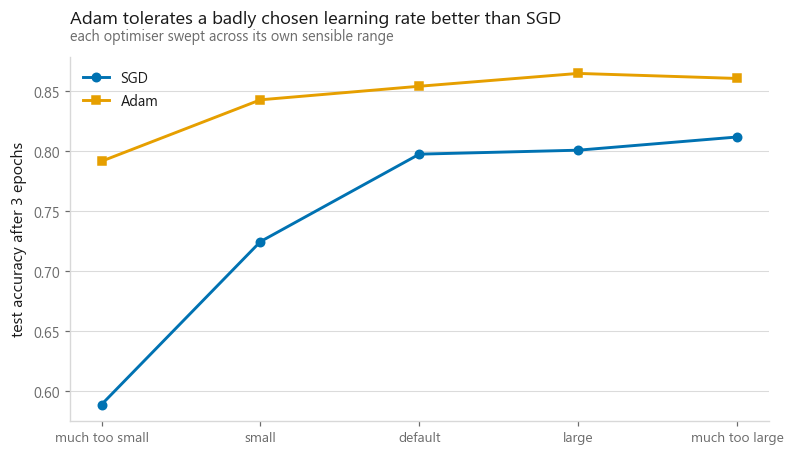

In [5]:
rates = {"SGD": [0.005, 0.02, 0.05, 0.2, 0.5],
         "Adam": [0.0001, 0.0005, 0.001, 0.005, 0.02]}
sensitivity = {}

for name, options in rates.items():
    scores = []
    for lr in options:
        model = build()
        loss_fn = nn.CrossEntropyLoss()
        optimiser = (torch.optim.SGD(model.parameters(), lr=lr) if name == "SGD"
                     else torch.optim.Adam(model.parameters(), lr=lr))
        for _ in range(3):
            model.train()
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                optimiser.zero_grad()
                loss_fn(model(xb), yb).backward()
                optimiser.step()
        model.eval()
        correct = 0
        with torch.no_grad():
            for xb, yb in test_loader:
                correct += (model(xb.to(device)).argmax(1) == yb.to(device)).sum().item()
        scores.append(correct / len(test_set))
    sensitivity[name] = scores
    print(f"{name}: " + "  ".join(f"lr={lr}: {s:.3f}" for lr, s in zip(options, scores)))

fig, ax = plt.subplots(figsize=(8.2, 4.3))
for i, (name, scores) in enumerate(sensitivity.items()):
    ax.plot(range(len(scores)), scores, marker=style.MARKERS[i], color=style.PALETTE[i],
            label=name)
ax.set_xticks(range(5), ["much too small", "small", "default", "large", "much too large"],
              fontsize=9)
ax.set_ylabel("test accuracy after 3 epochs")
ax.legend()
style.title(ax, "Adam tolerates a badly chosen learning rate better than SGD",
            "each optimiser swept across its own sensible range")
style.save(fig, FIG / "fig-03-sensitivity.png")

for name, scores in sensitivity.items():
    print(f"{name}: spread across the sweep = {max(scores) - min(scores):.3f}")

This is the real reason Adam is the default in most codebases. Not that it finds
better minima (the evidence for that is mixed and dataset-dependent), but that
**it works acceptably over a much wider range of learning rates.** When you are
trying a new architecture and have no idea what rate to use, that is worth more
than a fraction of a percent of final accuracy.

The counter-argument, worth knowing: well-tuned SGD with momentum still wins many
vision benchmarks, and models trained with it often generalise slightly better.
If you are going to tune carefully anyway, SGD with momentum is not obsolete.

## Cheat sheet

| | |
|---|---|
| **Start with** | Adam at `lr=1e-3`. It is the default because it is forgiving |
| **Switch to SGD + momentum when** | You are tuning carefully, training a vision model, or chasing the last fraction of accuracy |
| **Momentum fixes** | Zig-zagging in ravines, by averaging directions that keep reversing |
| **RMSProp fixes** | One learning rate for all parameters, by scaling each by its own gradient history |
| **Adam** | Both, plus bias correction for the cold start |
| **AdamW** | Adam with weight decay applied correctly. Prefer it when you use weight decay at all |
| **Watch out** | Learning rate still matters more than the optimiser. Tune it first |

## What to remember

1. Every optimiser after SGD fixes a named failure: ravines, or one rate for all
   parameters.
2. Momentum averages gradients; RMSProp scales by their squares; Adam does both.
3. On a 2-D ravine the ordering is dramatic. On a real network it is much less so.
4. Adam's real advantage is tolerance to a badly chosen learning rate.
5. Tune the learning rate before you agonise over the optimiser.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [07-06 Regularisation](../06-regularisation/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#DeepLearning` `#Optimizers` `#Adam` `#SGD` `#Momentum` `#RMSProp`
`#PyTorch` `#MachineLearning` `#MLTutorial` `#GradientDescent`